# **Email Spam Detection using Machine Learning**

# **Project Overview**

This project aims to build a machine learning model that can classify emails as Spam or Not Spam (Ham) using Natural Language Processing techniques.

## **Objectives**
*   Perform text preprocessing
*   Convert text into numerical features using
*   TF-IDF
*   Train classification models
*   Evaluate performance








# **1. Import Required Libraries**

In this step, we import all necessary libraries required for data analysis, visualization, text preprocessing, and machine learning model building.

In [47]:
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For better visualizations
import re  # For text cleaning using regular expressions

# **2.Load Dataset**

We load the dataset containing labeled email messages. The dataset includes two main columns:


*   Label (Spam/Ham)
*   Message (Email content)






In [49]:
df = pd.read_csv("spam.csv", encoding='latin-1')

# **3.Data Cleaning**

We remove unnecessary columns and rename the remaining columns for better readability and understanding.

In [50]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# **Step 4: Label Encoding**

Convert categorical labels into numerical format:

*   Ham → 0
*   Spam → 1






In [51]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# **5. Exploratory Data Analysis**

We visualize the distribution of spam and non-spam emails to understand the dataset balance.

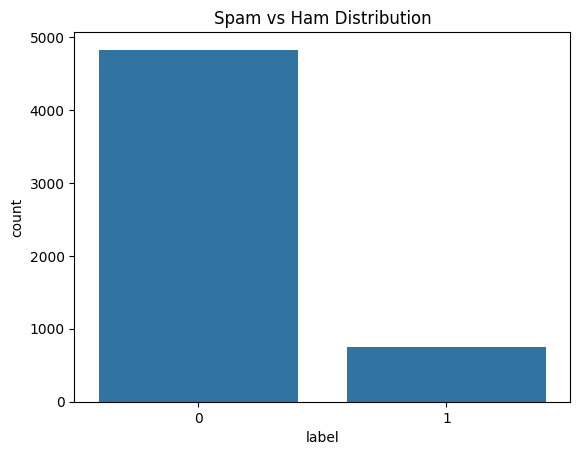

,count
label,
0,4825
1,747


In [52]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

df['label'].value_counts()

# **6: Text Preprocessing**

We clean the text by:

*   Converting to lowercase
*   Removing numbers
*   Removing punctuation
*   Removing extra spaces







In [53]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['message'] = df['message'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **7. Train-Test Split**

We split the dataset into training and testing sets to evaluate model performance.

In [54]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **8. Feature Extraction (TF-IDF)**

Convert text data into numerical format using TF-IDF, which captures word importance.

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# **9. Model Training**

We use Multinomial Naive Bayes, which is highly effective for text classification.

In [56]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

# **10. Model Evaluation**

Evaluate performance using accuracy and classification report.

In [57]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9704035874439462
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.78      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



# **11. Save Model**

Save the trained model and vectorizer for future use.

In [58]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

# **12: Prediction System**

Create a function to classify new email messages.

In [59]:
def predict_spam(message):
    message = clean_text(message)
    vector = vectorizer.transform([message])
    result = model.predict(vector)

    return "Spam" if result[0] == 1 else "Not Spam"

In [60]:
print(predict_spam("Congratulations! You won a free prize"))



Spam


In [61]:
print(predict_spam("Let's meet tomorrow"))

Not Spam
